In [11]:
library(readr)
library(dplyr)
source("../../Common/func.R")

## FRG - Average yearly natural gas consumption

In [12]:
# Read CSV file
FRG <- read_csv("../../../data/NaturalGas_WHG.csv", show_col_types = FALSE)
# Summary of the data
glimpse(FRG)

Rows: 1,051,200
Columns: 4
$ unix_ts   <dbl> 1333263600, 1333263660, 1333263720, 1333263780, 1333263840, …
$ counter   <dbl> 559900, 559900, 559900, 559900, 559900, 559900, 559900, 5599…
$ avg_rate  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ inst_rate <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


In [13]:
# Convert unix timestamp (int) column to readable/usable columns
FRG <- convert_timeStamp(FRG, "unix_ts") %>%
    mutate(avg_rate_modif = avg_rate / 60)

In [14]:
head(FRG, 5)

unix_ts,counter,avg_rate,inst_rate,timeStamp,date,year,month,day,hour,minute,avg_rate_modif
<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<date>,<int>,<int>,<int>,<int>,<int>,<dbl>
1333263600,559900,0,0,2012-04-01 15:00:00,2012-04-01,2012,4,1,15,0,0
1333263660,559900,0,0,2012-04-01 15:01:00,2012-04-01,2012,4,1,15,1,0
1333263720,559900,0,0,2012-04-01 15:02:00,2012-04-01,2012,4,1,15,2,0
1333263780,559900,0,0,2012-04-01 15:03:00,2012-04-01,2012,4,1,15,3,0
1333263840,559900,0,0,2012-04-01 15:04:00,2012-04-01,2012,4,1,15,4,0


In [15]:
# Compute the average yearly consumption of natural gas (meter squared)
FRG_Total_Consumption <- yearly_consumption(FRG, "avg_rate_modif")

# Display the result
FRG_Total_Consumption %>%
    mutate(JG = yearly_consumption_v2 * 0.0373)

nDays,total_consumption,yearly_consumption_v1,yearly_consumption_v2,JG
<int>,<dbl>,<dbl>,<dbl>,<dbl>
731,2469.175,1232.899,1234.588,46.05011


## Temperature & Natural Gas

In [51]:
temp <- read_csv("../../../data/Climate_HourlyWeather.csv", show_col_types = FALSE) %>%
    select(`Date/Time`, Year, Month, Day, `Temp (C)`, `Data Quality`, `Temp Flag`) %>%
    rename(timeStamp = `Date/Time`)

head(temp, 5)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


timeStamp,Year,Month,Day,Temp (C),Data Quality,Temp Flag
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
2012-04-01 00:00:00,2012,4,1,4.3,NA,NA
2012-04-01 01:00:00,2012,4,1,4.4,NA,NA
2012-04-01 02:00:00,2012,4,1,3.8,NA,NA
2012-04-01 03:00:00,2012,4,1,2.8,NA,NA
2012-04-01 04:00:00,2012,4,1,2.4,NA,NA


In [35]:
FRGHourly <- FRG %>%
    group_by(date, year, month, day, hour) %>%
    summarise(
        unix_ts = first(unix_ts),
        timeStamp = first(timeStamp),
        consumption = sum(avg_rate) / 60
    )

`summarise()` has grouped output by 'date', 'year', 'month', 'day'. You can
override using the `.groups` argument.


In [36]:
FRG_Temp <- FRGHourly %>%
    left_join(temp, by = c("timeStamp"), suffix = c("_gas", "_temp"))

head(FRG_Temp, 5)

date,year,month,day,hour,unix_ts,timeStamp,consumption,Temp (C),Data Quality,Temp Flag
<date>,<int>,<int>,<int>,<int>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<lgl>
2012-04-01,2012,4,1,15,1333263600,2012-04-01 19:00:00,0,8.4,NA,NA
2012-04-01,2012,4,1,16,1333267200,2012-04-01 20:00:00,0,7.9,NA,NA
2012-04-01,2012,4,1,17,1333270800,2012-04-01 21:00:00,0,7.2,NA,NA
2012-04-01,2012,4,1,18,1333274400,2012-04-01 22:00:00,0,6.6,NA,NA
2012-04-01,2012,4,1,19,1333278000,2012-04-01 23:00:00,25,6.8,NA,NA


In [19]:
library(ggplot2)

In [59]:
TempMonthly <- temp %>% 
    group_by(Year, Month) %>% 
    summarise(
        avg_temp = mean(`Temp (C)`, na.rm = TRUE)
    )
head(TempMonthly, 3)

`summarise()` has grouped output by 'Year'. You can override using the
`.groups` argument.


Year,Month,avg_temp
<dbl>,<dbl>,<dbl>
2012,4,9.467917
2012,5,12.207661
2012,6,14.148611


In [60]:
FRGMonthly <- FRG %>%
    group_by(year, month) %>%
    summarise(
        consumption = sum(avg_rate) / 60
    )
head(FRGMonthly, 3)

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


year,month,consumption
<int>,<int>,<dbl>
2012,4,62375
2012,5,58350
2012,6,48850


In [77]:
myDF <- FRGMonthly %>%
    left_join(TempMonthly, by = c("year" = "Year", "month" = "Month")) %>% 
    ungroup() %>%
    mutate(
        avg_temp = ifelse(is.na(avg_temp), mean(avg_temp, na.rm = TRUE), avg_temp)
    )
head(myDF, 3)


year,month,consumption,avg_temp
<dbl>,<dbl>,<dbl>,<dbl>
2012,4,62375,9.467917
2012,5,58350,12.207661
2012,6,48850,14.148611


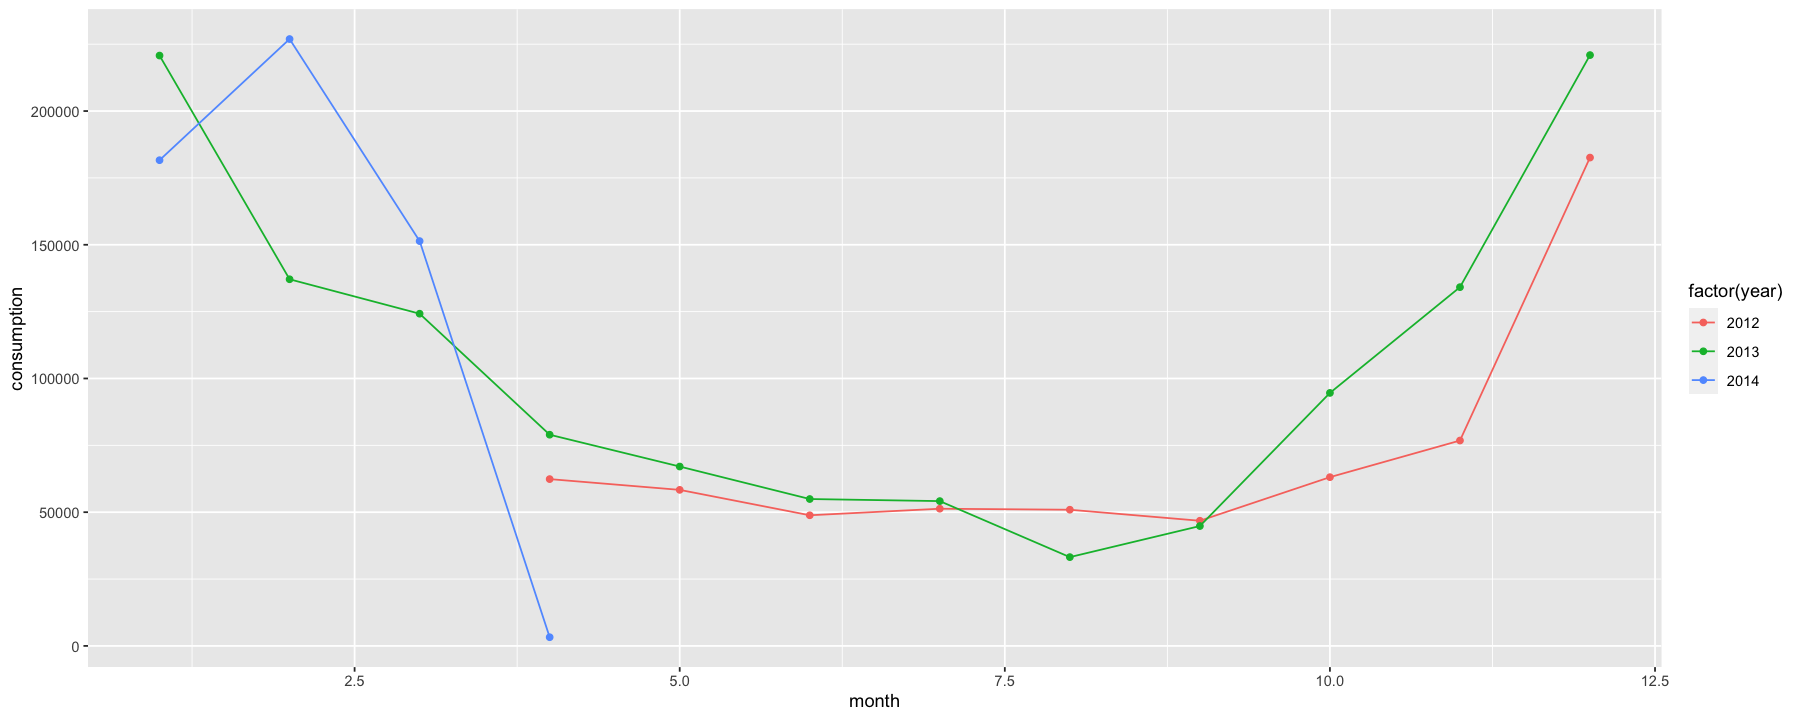

In [86]:
ggplot(myDF, aes(x = month, color = factor(year))) + 
    geom_point(aes(y = consumption)) +
    geom_line(aes(y = consumption))

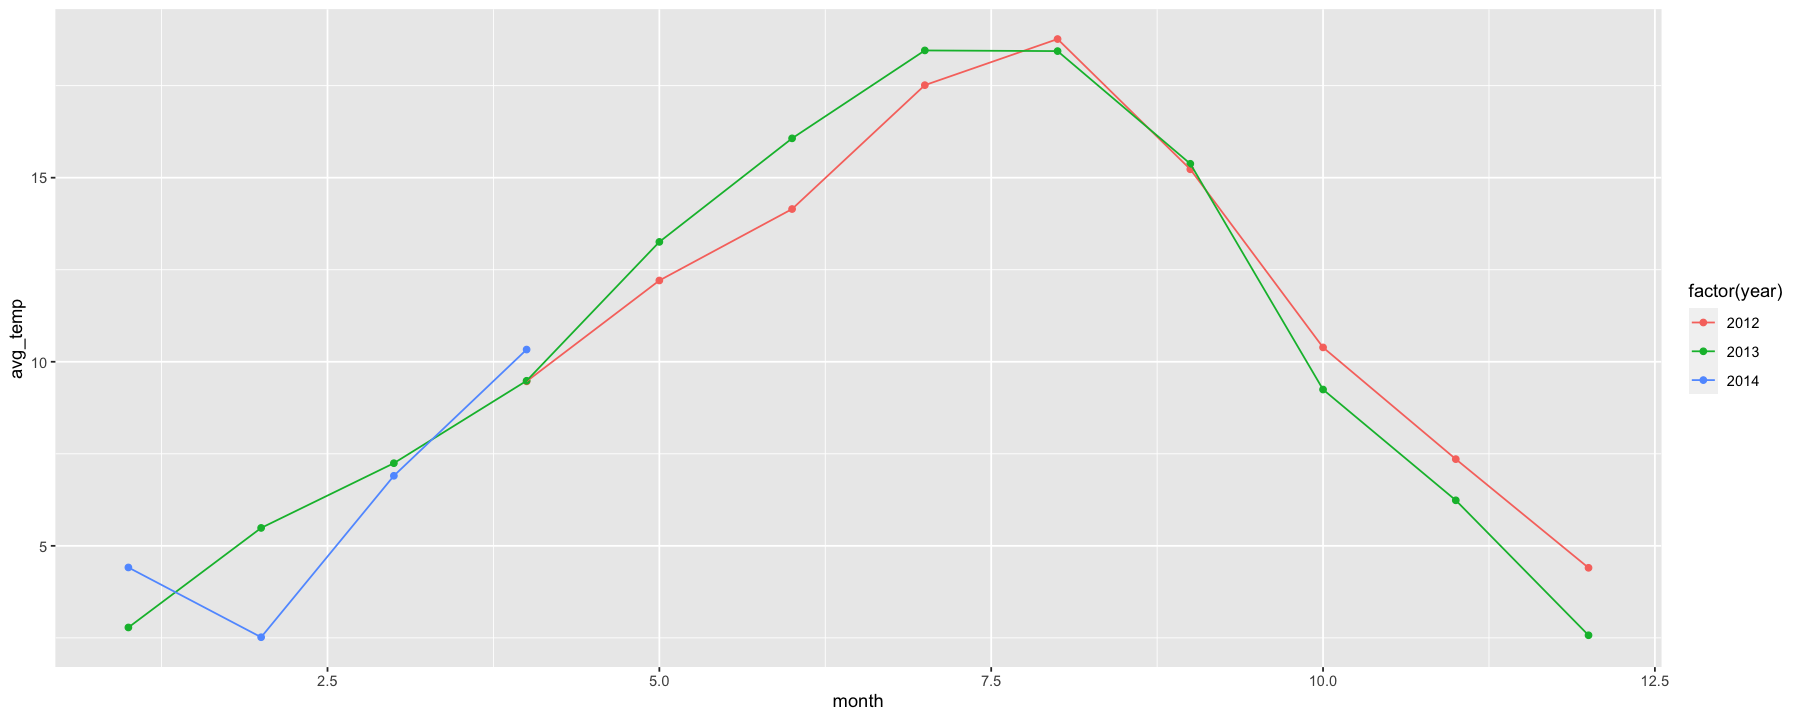

In [88]:
ggplot(myDF, aes(x = month, y = avg_temp, color = factor(year))) + 
    geom_point() +
    geom_line()

In [100]:
lmodel <- lm(consumption ~ avg_temp, data = myDF)
pmodel <- glm(as.formula("consumption ~ avg_temp"), data = myDF, family = poisson)

In [90]:
summary(lmodel)


Call:
lm(formula = consumption ~ avg_temp, data = myDF)

Residuals:
   Min     1Q Median     3Q    Max 
-95517 -15432  -1353  22321  47080 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   205971      15611  13.194 3.26e-12 ***
avg_temp      -10376       1348  -7.698 8.25e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 35280 on 23 degrees of freedom
Multiple R-squared:  0.7204,	Adjusted R-squared:  0.7082 
F-statistic: 59.26 on 1 and 23 DF,  p-value: 8.247e-08


In [92]:
library(broom)

In [101]:
perf <- glance(pmodel)
(pseudoR2 <- 1 - perf$deviance/perf$null.deviance)

[1] 0.7816855

In [102]:
myDF$pred <- predict(pmodel, myDF, type = "response")

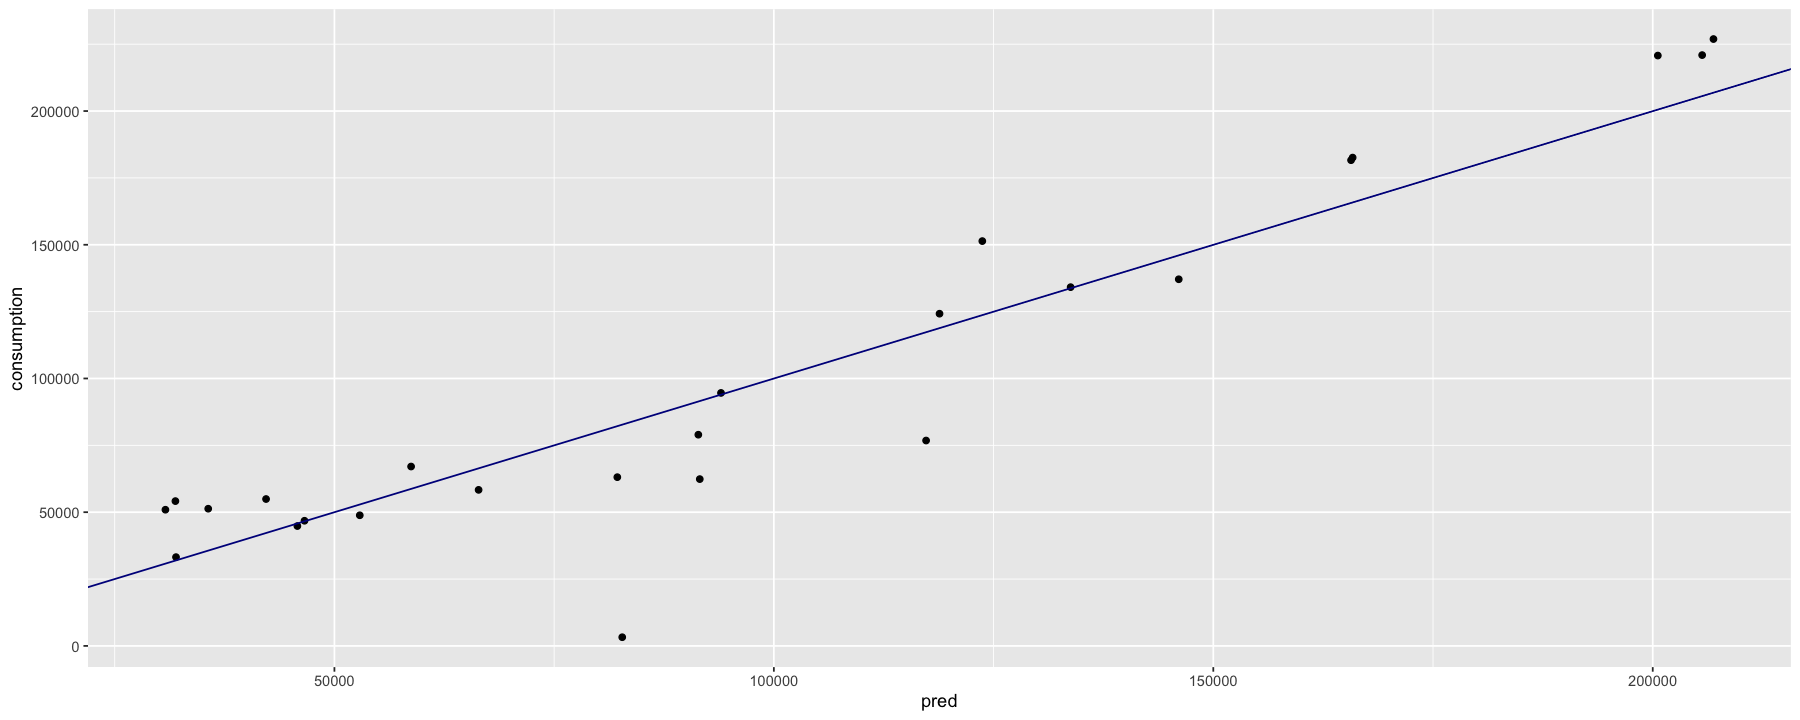

In [104]:
ggplot(myDF, aes(x = pred, y = consumption)) +
    geom_point() +
    geom_abline(color = "darkblue")

In [ ]:
FRGMonthly %>%
    ggplot(aes(x = factor(month), y = consumption, group = year, color = factor(year))) +
    geom_point() +
    geom_line()

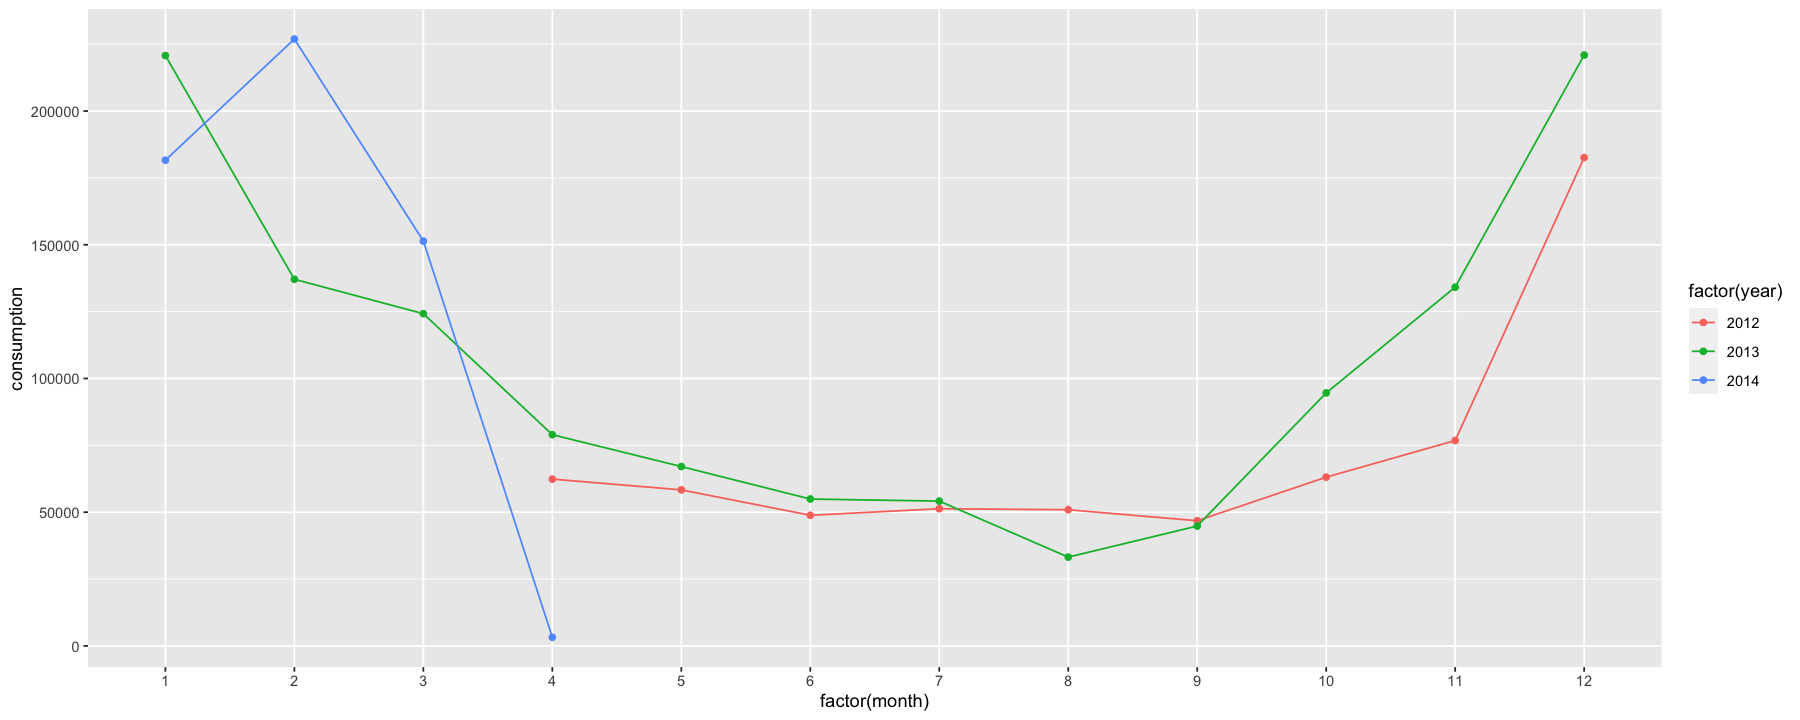

In [47]:
FRGMonthly %>%
    ggplot(aes(x = factor(month), y = consumption, group = year, color = factor(year))) +
    geom_point() +
    geom_line()